In [ ]:
import numpy as np
from tensorflow.keras.optimizers import Adam
from keras import utils as np_utils
from keras.layers import Activation, Dropout, Convolution2D, GlobalAveragePooling2D
from keras.models import Sequential
import tensorflow as tf
import tensorflow.keras.applications.mobilenet
import os

In [ ]:
#IMG_SAVE_PATH = r'/kaggle/input/skin-disease-classification-image-dataset/Split_smol/train'

In [ ]:
Str_to_Int = {
    'Actinic keratosis': 0,
    'Atopic Dermatitis': 1,
    'Benign keratosis': 2,
    'Dermatofibroma': 3,
    'Melanocytic nevus': 4,
    'Melanoma':5,
    'Squamous cell carcinoma': 6,
    'Tinea Ringworm Candidiasis':7,
    'Vascular lesion': 8
}

NUM_CLASSES = 9


def str_to_Int_mapper(val):
    return Str_to_Int[val]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMG_SAVE_PATH = r'/content/drive/MyDrive/Split_smol/train'

In [ ]:
import PIL
import cv2

dataset = []
for directory in os.listdir(IMG_SAVE_PATH):
    path = os.path.join(IMG_SAVE_PATH, directory)
    for image in os.listdir(path):
        new_path = os.path.join(path, image)
        try:
            imgpath=PIL.Image.open(new_path)
            #if imgpath.shape!=(240,240,3):
            imgpath=imgpath.convert('RGB')
            img = np.asarray(imgpath)
            img = cv2.resize(img, (240,240))
            img=img/255.
            dataset.append([img, directory])
        except FileNotFoundError:
            print('Image file not found. Skipping...')

In [ ]:
data, labels = zip(*dataset)
temp = list(map(str_to_Int_mapper, labels))

In [ ]:
import keras
labels = keras.utils.to_categorical(temp)

In [ ]:
count=0
for i in data:
    if i.shape!=(240, 240, 3):
        count=count+1
print(count)

0


In [ ]:
from keras.applications import DenseNet121
from keras.callbacks import Callback, ModelCheckpoint
from tensorflow.keras import layers

densenet = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(240,240,3)
)

def build_densenet():
    model = Sequential()
    model.add(densenet)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(9, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.00005),
        metrics=['accuracy']
    )

    return model


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = build_densenet()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,046,729 (26.88 MB)

 Trainable params: 6,963,081 (26.56 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
history=model.fit(np.array(data), np.array(labels), epochs = 5, shuffle = True, validation_split = 0.2)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 672s 32s/step - accuracy: 0.1517 - loss: 0.7135 - val_accuracy: 0.1214 - val_loss: 0.5729
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 571s 32s/step - accuracy: 0.3846 - loss: 0.5113 - val_accuracy: 0.1286 - val_loss: 0.5426
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 548s 30s/step - accuracy: 0.5328 - loss: 0.3808 - val_accuracy: 0.1000 - val_loss: 0.5217
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 567s 32s/step - accuracy: 0.6833 - loss: 0.2950 - val_accuracy: 0.0714 - val_loss: 0.4958
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 547s 30s/step - accuracy: 0.8106 - loss: 0.2266 - val_accuracy: 0.1071 - val_loss: 0.4738


In [ ]:
import seaborn as sns
from matplotlib import pyplot

def plot_acc(history):
    sns.set()

    fig = pyplot.figure(0, (12, 4))

    ax = pyplot.subplot(1, 2, 1)
    sns.lineplot(x=history.epoch, y=history.history['accuracy'], label='train')
    sns.lineplot(x=history.epoch, y=history.history['val_accuracy'], label='valid')
    pyplot.title('Accuracy')
    pyplot.tight_layout()

    ax = pyplot.subplot(1, 2, 2)
    sns.lineplot(x=history.epoch, y=history.history['loss'], label='train')
    sns.lineplot(x=history.epoch, y=history.history['val_loss'], label='valid')
    pyplot.title('Loss')
    pyplot.tight_layout()

    pyplot.show()

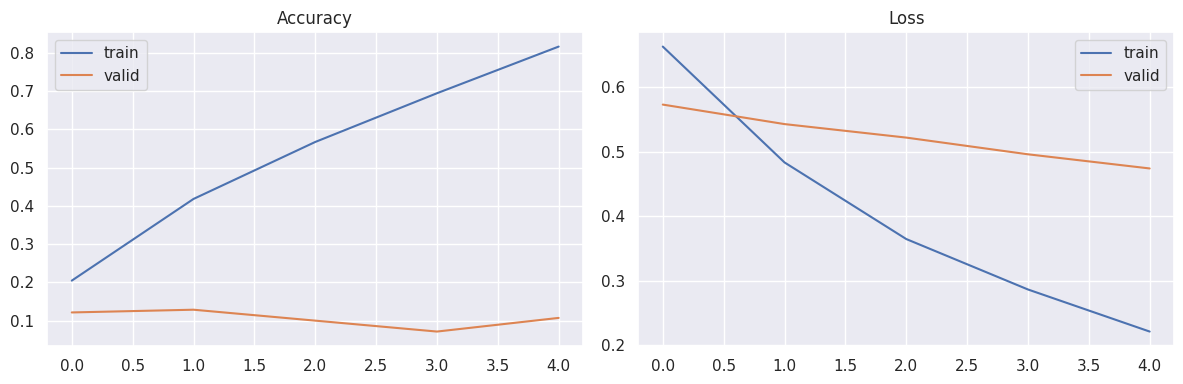

In [ ]:
plot_acc(history)

In [ ]:
def mobilenet():
    model = Sequential([
        tf.keras.applications.mobilenet.MobileNet(input_shape=(240,240, 3), include_top=False),
        Dropout(0.5),
        Convolution2D(9, (1, 1), padding='valid'),
        Activation('relu'),        # Rectified Linear Unit - Activation Function
        GlobalAveragePooling2D(),  # Pooling Layer
        Activation('softmax')      # Softmax - Activation Function - For Multi Class Classification
    ])
    return model

In [ ]:
# define the model
model_mobile = mobilenet()
model_mobile.compile(
    optimizer=Adam(learning_rate=0.0001),         # lr = learning_rate
    loss='categorical_crossentropy',   # Multi-class classification
    metrics=['accuracy']
)

/tmp/ipython-input-630773363.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  tf.keras.applications.mobilenet.MobileNet(input_shape=(240,240, 3), include_top=False),


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_mobile.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 9)        │         9,225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 7, 7, 9)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 9)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,238,089 (12.35 MB)

 Trainable params: 3,216,201 (12.27 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
history_mobile=model_mobile.fit(np.array(data), np.array(labels), epochs = 5, shuffle = True, validation_split = 0.3)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 159s 9s/step - accuracy: 0.2891 - loss: 1.9511 - val_accuracy: 0.0000e+00 - val_loss: 3.6772
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 132s 8s/step - accuracy: 0.8366 - loss: 0.5610 - val_accuracy: 0.0190 - val_loss: 3.5669
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 141s 8s/step - accuracy: 0.9473 - loss: 0.2373 - val_accuracy: 0.0524 - val_loss: 3.4216
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 139s 8s/step - accuracy: 0.9887 - loss: 0.1314 - val_accuracy: 0.1190 - val_loss: 3.1346
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 129s 8s/step - accuracy: 0.9897 - loss: 0.0732 - val_accuracy: 0.1524 - val_loss: 3.0528


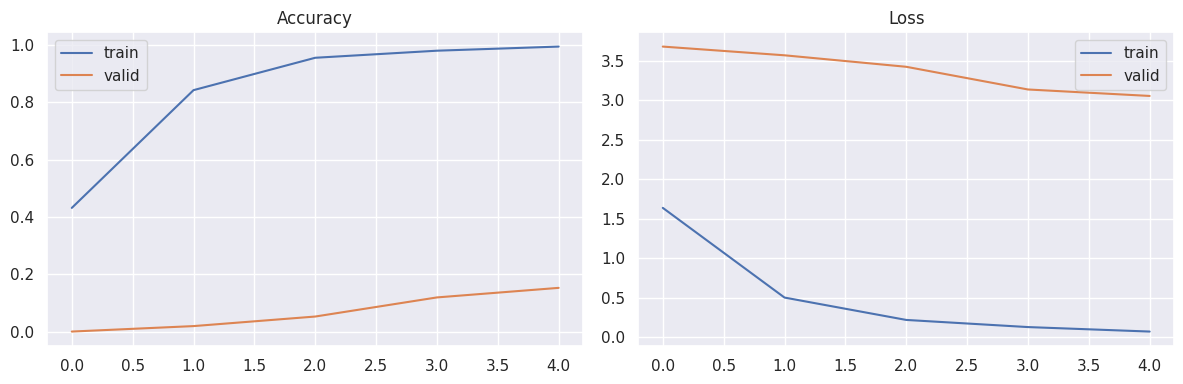

In [ ]:
plot_acc(history_mobile)

In [ ]:
def cnn():
    model=Sequential()

    model.add(Conv2D(8, kernel_size=(3,3), activation='relu', input_shape=(240,240,3)))
    model.add(Conv2D(16, kernel_size=(3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(9, activation='softmax'))

    return model

In [ ]:
from keras.layers import Dense , Dropout , Conv2D , MaxPooling2D, Flatten
model_cnn=cnn()
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),         # lr = learning_rate
    loss='categorical_crossentropy',   # Multi-class classification
    metrics=['accuracy']
)

In [ ]:
model_cnn.summary()

In [ ]:
history_cnn=model_cnn.fit(np.array(data), np.array(labels), epochs = 5, shuffle = True, validation_split = 0.25)

In [ ]:
plot_acc(history_cnn)

In [ ]:
model.save("skin_disease_model_ISIC_densenet.h5")

In [ ]:
IMG_SAVE_PATH_TESTING = r'/kaggle/input/skin-disease-classification-image-dataset/Split_smol/val'

In [ ]:
import PIL
import cv2
dataset_testing = []
for directory in os.listdir(IMG_SAVE_PATH_TESTING):
    path = os.path.join(IMG_SAVE_PATH_TESTING, directory)
    for image in os.listdir(path):
        new_path = os.path.join(path, image)
        imgpath=PIL.Image.open(new_path)
        #if imgpath.shape!=(240,240,3):
        imgpath=imgpath.convert('RGB')
        img = np.asarray(imgpath)
#         img = cv2.imread(new_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (240, 240))
        img=img/255.
        dataset_testing.append([img, directory])

In [ ]:
testing_data, testing_labels = zip(*dataset_testing)